# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | Elegir dos medios comparables sobre el conflicto Irán-EEUU | Pedimos sugerencias de corpus y criterios de comparabilidad | Propuso comparar Infobae y La Nación por sus diferencias editoriales y accesibilidad técnica | Se conservó la sugerencia de medios y el criterio de temporalidad compartida | Se descartó Página 12 porque su sitio bloquea la extracción automática de texto |
| Procesamiento con spaCy | Descargar artículos y armar el CSV con las columnas requeridas | Pedimos un script de Trafilatura para bajar los textos y generar el archivo | Generó el script de descarga con extracción de fecha desde la URL y guardado en UTF-8 | Se conservó el script completo porque funcionó en todos los artículos de ambos medios | No se descartó nada; se ajustó la selección de artículos por longitud |
| Representaciones sparse | Ejecutar el notebook y entender los resultados de BoW y TF-IDF | Consultamos qué significaba la diferencia entre frecuencia y peso TF-IDF | Explicó que TF-IDF descarta términos compartidos y resalta los exclusivos de cada grupo | Se conservó esa distinción para la interpretación del heatmap | No se descartó nada |
| Visualización | Interpretar el heatmap de términos distintivos | Pedimos una lectura de los términos que aparecían en cada columna | Identificó el frame económico en Infobae y el frame militar-geopolítico en La Nación | Se conservó como punto de partida para la escritura interpretativa | Se revisó contra los fragmentos antes de aceptar las hipótesis |
| Interpretación final | Redactar las respuestas del punto 10 | Pedimos borradores para las 4 preguntas interpretativas | Produjo textos apoyados en los términos y fragmentos obtenidos del corpus | Se conservaron los borradores con ajustes propios sobre los fragmentos leídos | Se descartaron generalizaciones que no tenían respaldo directo en los textos |



## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [1]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [2]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_tpi2.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_tpi2.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [3]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 10
Grupos detectados: ['infobae', 'lanacion']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,1,2026-04-26,Infobae,Redacción,"No solo petróleo, gas y fertilizantes: la Guerra en Medio Oriente también disparó el precio mundial del pistacho",infobae,759
1,2,2026-04-27,Infobae,Redacción,Trump dijo que no tiene prisa en negociar con Irán y aseguró que la estrategia de máxima presión ha debilitado al régimen,infobae,521
2,3,2026-04-26,Infobae,Redacción,El canciller iraní viaja a Moscú para reunirse con Putin en medio de la parálisis del diálogo con Estados Unidos,infobae,624
3,4,2026-04-26,Infobae,Redacción,Las negociaciones en Pakistán están en suspenso mientras Irán abandona Islamabad y los enviados de Trump no se presentan,infobae,872
4,5,2026-03-30,Infobae,Redacción,"La Casa Blanca afirma que EEUU ""no necesita ayuda de España ni de nadie más"" en la guerra contra Irán",infobae,805
5,6,2026-04-26,La Nación,Redacción,"Día 59 de la guerra entre Estados Unidos, Israel e Irán: todo lo que hay que saber",lanacion,642
6,7,2026-04-24,La Nación,Redacción,Cómo la guerra en Irán pasó de los bombardeos a una prueba de voluntades,lanacion,1132
7,8,2026-04-26,La Nación,Redacción,Trump desafía a Irán a negociar mientras su canciller viaja a Moscú para reunirse con Putin,lanacion,977
8,9,2026-04-25,La Nación,Redacción,Trump cancela a último momento el viaje a Pakistán tras el desplante de Irán: “No vamos a hablar de la nada”,lanacion,1081
9,10,2026-04-23,La Nación,Redacción,¿Funcionará en Irán la herramienta favorita de Trump?,lanacion,1101


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


Comparamos la cobertura del conflicto bélico entre Estados Unidos, Israel e Irán en 
**Infobae** y **La Nación**, dos medios digitales argentinos de alcance masivo pero 
con líneas editoriales distintas.

Los dos grupos son comparables porque cubren la misma temática en el mismo período 
(marzo-abril de 2026) y ambos son medios de referencia en Argentina. Lo que los 
diferencia es el enfoque: Infobae tiende a un registro más popular e inmediato, 
La Nación a un análisis más político y de largo plazo.

**Límites iniciales del recorte:**
- Todos los artículos están firmados por "Redacción", lo que impide comparar voces 
  autorales individuales.
- Un artículo de Infobae (el del pistacho) introduce vocabulario comercial que puede 
  sesgar los términos distintivos del grupo.
- El corpus es pequeño (5 artículos por grupo), por lo que los resultados orientan 
  pero no permiten generalizaciones.


## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [4]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,10
1,palabras aproximadas,8514
2,promedio por texto,851.4
3,grupo 1,infobae
4,grupo 2,lanacion


In [5]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,infobae,5,3581,716.2
1,lanacion,5,4933,986.6


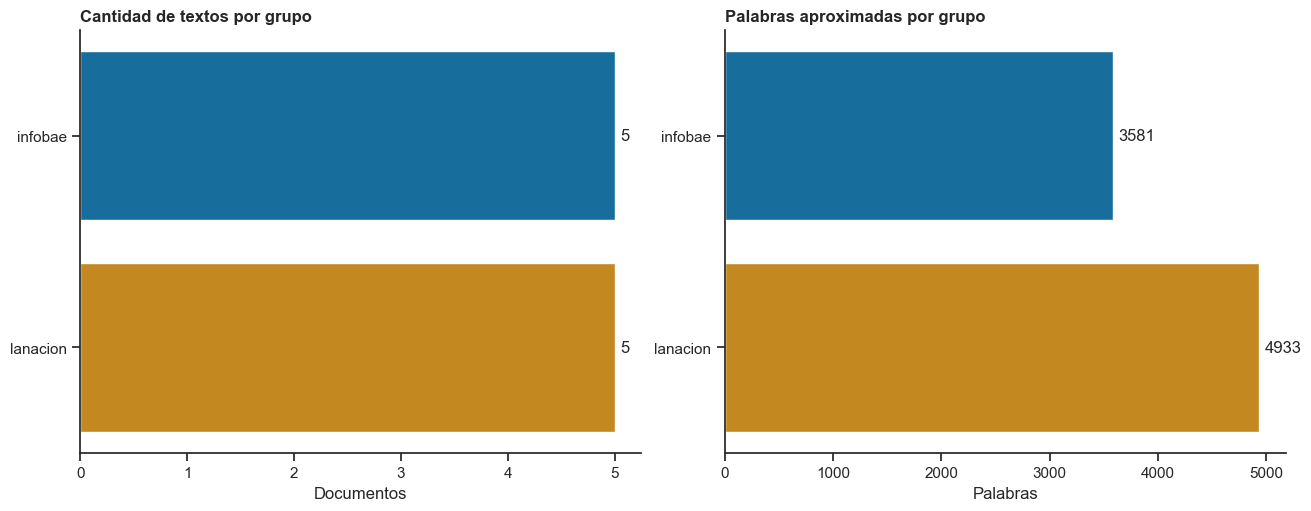

In [6]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [7]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_sm


In [8]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


,titulo,grupo_comparacion,texto_contenido
0,"No solo petróleo, gas y fertilizantes: la Guerra en Medio Oriente también disparó el precio mundial del pistacho",infobae,febrero celebrar mundial pistacho iniciar guerra oriente israel enfrentar principal productor mundial fruto seco año poner moda unidos p...
1,Trump dijo que no tiene prisa en negociar con Irán y aseguró que la estrategia de máxima presión ha debilitado al régimen,infobae,administración donald trump decidir convertir factor tiempo principal herramienta coacción geopolítico frente irán entrevista concedido ...
2,El canciller iraní viaja a Moscú para reunirse con Putin en medio de la parálisis del diálogo con Estados Unidos,infobae,ministro relaciones exteriores irán abbas araghchi partir domingo rumbo moscú encuentro presidente vladimir putin serie reunión pakistán...
3,Las negociaciones en Pakistán están en suspenso mientras Irán abandona Islamabad y los enviados de Trump no se presentan,infobae,intento entablar conversación alto fuego unidos irán fracasar principal diplomático teherán abandonara pakistán enviado presidente donal...
4,"La Casa Blanca afirma que EEUU ""no necesita ayuda de España ni de nadie más"" en la guerra contra Irán",infobae,medida adoptado recientemente gobierno español impedir avión implicado operación furia épica utilizar base rota morón espacio aéreo espa...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [9]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,infobae,irán,43
1,infobae,unidos,21
2,infobae,militar,20
3,infobae,mantener,16
4,infobae,israel,15
5,infobae,año,15
6,infobae,estadounidense,15
7,infobae,país,14
8,infobae,iraní,14
9,infobae,trump,14


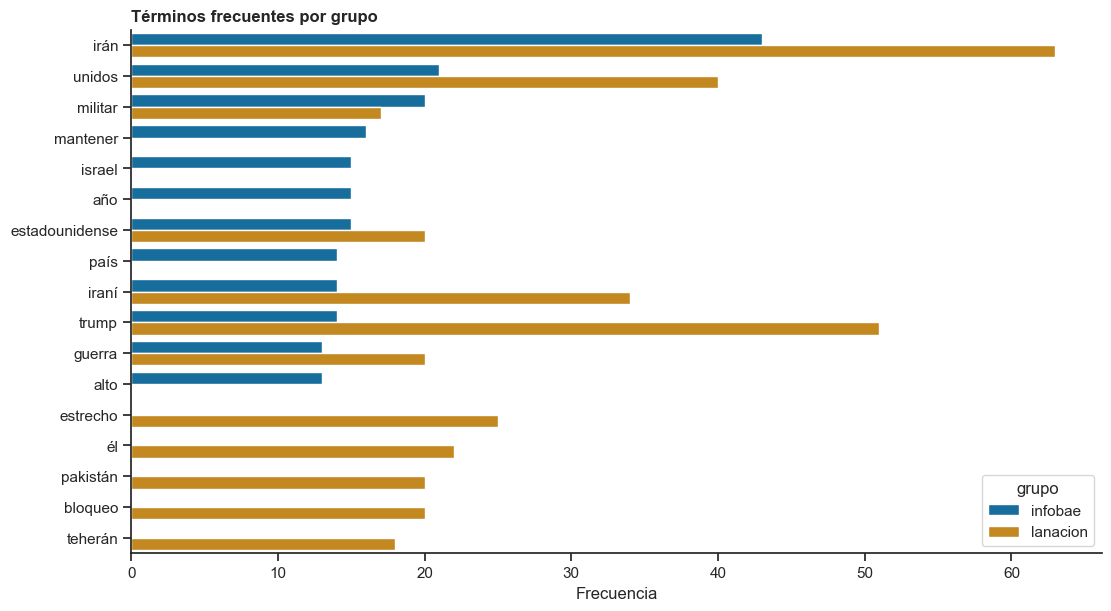

In [10]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [11]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
52,infobae,Irán,LOC,38
33,infobae,Estados Unidos,LOC,20
54,infobae,Israel,LOC,15
48,infobae,Hezbollah,ORG,8
73,infobae,Líbano,LOC,8
124,infobae,estrecho de Ormuz,LOC,8
111,infobae,Teherán,PER,7
113,infobae,Trump,PER,7
95,infobae,Pakistán,LOC,6
117,infobae,Washington,LOC,6


In [12]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,infobae,alto fuego,9
1,infobae,estrecho ormuz,9
2,infobae,europa press,8
3,infobae,casa blanca,6
4,infobae,gobierno español,5
5,infobae,rota morón,4
6,infobae,unidos israel,4
7,infobae,puerto iraní,4
8,infobae,donald trump,4
9,infobae,operación furia,4


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [13]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,infobae,febrero celebrar mundial pistacho iniciar guerra oriente israel enfrentar principal productor mundial fruto seco año poner moda unidos p...
1,lanacion,reporte jornada entender ofensiva militar represalia creciente temor expansión enfrentamiento minuto lectura conflicto oriente entrar lu...


In [14]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,infobae,español,12.0
1,infobae,pistacho,11.0
2,infobae,press,10.0
3,infobae,europa,10.0
4,infobae,internacional,9.0
5,infobae,españa,8.0
6,infobae,producción,8.0
7,infobae,acción,8.0
8,infobae,argentina,6.0
9,infobae,inicio,6.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,infobae,español,0.2825
1,infobae,pistacho,0.2589
2,infobae,press,0.2354
3,infobae,europa,0.2354
4,infobae,internacional,0.2118
5,infobae,españa,0.1883
6,infobae,producción,0.1883
7,infobae,acción,0.1883
8,infobae,argentina,0.1412
9,infobae,inicio,0.1412


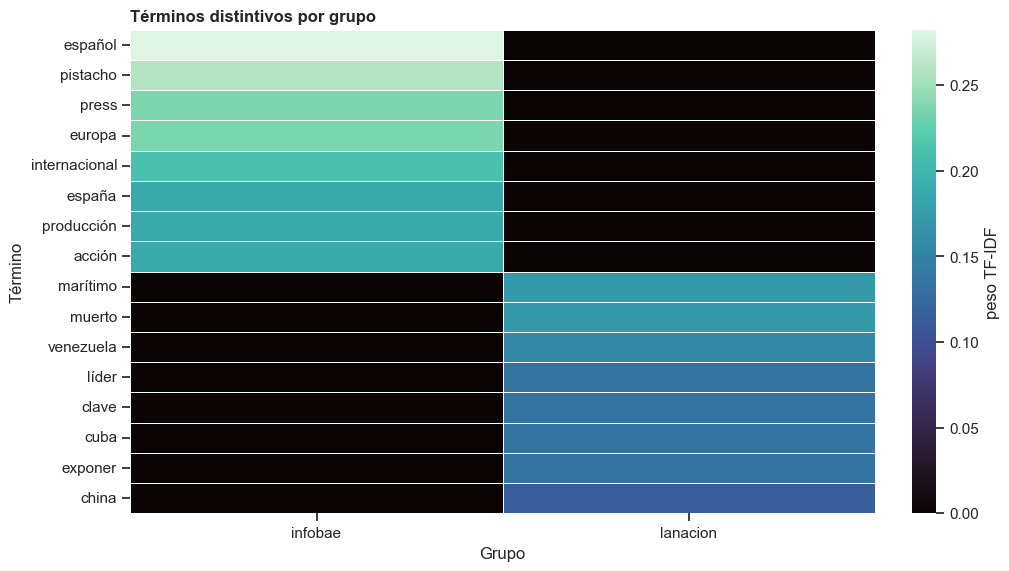

In [15]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [16]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,infobae,español,0.2825
1,infobae,pistacho,0.2589
2,lanacion,marítimo,0.1731
3,lanacion,muerto,0.1731


In [17]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,infobae,español,"La Casa Blanca afirma que EEUU ""no necesita ayuda de España ni de nadie más"" en la guerra contra Irán",Las medidas adoptadas recientemente por el Gobierno español han impedido que aviones implicados en la operación 'Furia Épica' utilicen t...
1,infobae,pistacho,"No solo petróleo, gas y fertilizantes: la Guerra en Medio Oriente también disparó el precio mundial del pistacho","El 26 de febrero pasado se celebró el “Día mundial del Pistacho”. Dos días después, el 28, se inició la Guerra en Medio Oriente, que ade..."
2,lanacion,marítimo,Cómo la guerra en Irán pasó de los bombardeos a una prueba de voluntades,"...nsión en el estrecho de Ormuz puede escalar rápidamente, ya que tanto Irán como Estados Unidos buscan demostrar firmeza en ese angost..."
3,lanacion,marítimo,Trump desafía a Irán a negociar mientras su canciller viaja a Moscú para reunirse con Putin,"...leo, alimentó la inflación y deterioró las perspectivas de crecimiento global.\nEn este escenario, Irán reclama el levantamiento del ..."
4,lanacion,marítimo,¿Funcionará en Irán la herramienta favorita de Trump?,"...e supervisa Oriente Medio dijo que, hasta el miércoles, ha ordenado a 31 barcos dar la vuelta o regresar a puerto.\nLos grupos de tra..."
5,lanacion,muerto,Trump cancela a último momento el viaje a Pakistán tras el desplante de Irán: “No vamos a hablar de la nada”,"...minados, mientras vigilamos el comportamiento y los movimientos de los enemigos”, sentenció.\nWashington y Teherán se encuentran en u..."


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?
   

      Comparamos la cobertura del conflicto bélico entre Estados Unidos, Israel e Irán 
      en dos medios digitales argentinos de alcance masivo: **Infobae** y **La Nación**. 
      Ambos grupos reúnen 5 artículos publicados entre marzo y abril de 2026, lo que los 
      vuelve comparables en temporalidad y temática. Lo que los diferencia es su línea 
      editorial y su modo de enmarcar el mismo conflicto: Infobae apunta a un público 
      amplio con fuerte énfasis en consecuencias económicas, mientras que La Nación 
      privilegia el análisis geopolítico y militar. Esa diferencia de enfoque es lo que 
      motiva la comparación.

      Un límite inicial del recorte es que todos los artículos están firmados por 
      "Redacción", lo que impide comparar estilos de autor. Otro límite es que el corpus 
      de Infobae incluye un artículo sobre el pistacho que introduce vocabulario comercial 
      que sesga los términos distintivos del grupo.



2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

   
      Los términos que organizan cada grupo son claramente distintos. En **Infobae**, los 
      términos con mayor peso TF-IDF son "español" (0.28), "pistacho" (0.26), "europa", 
      "españa" y "producción". Este vocabulario revela un encuadre económico y comercial 
      del conflicto: la guerra aparece como un evento que impacta mercados, cadenas de 
      suministro y actores europeos.

      En **La Nación**, los términos más distintivos son "marítimo" (0.17), "muerto" 
      (0.17), "venezuela", "cuba", "china" y "bomba". Este vocabulario construye un 
      encuadre militar y geopolítico: la guerra se narra como una confrontación entre 
      potencias con consecuencias en el control naval y en alianzas internacionales.

      La diferencia entre BoW y TF-IDF es relevante aquí: palabras como "Irán", "Trump" 
      o "negociar" aparecen en ambos grupos con alta frecuencia, pero TF-IDF las descarta 
      como poco distintivas. Lo que TF-IDF revela es el vocabulario *exclusivo* de cada 
      encuadre, que no sería visible si solo miráramos frecuencias brutas.


3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?
   

      **"Pistacho" en Infobae**: el fragmento muestra que el artículo abre con el Día 
      Mundial del Pistacho y conecta esa celebración con el inicio de la guerra dos días 
      después. Esta elección editorial es significativa: en lugar de abrir con bajas o 
      movimientos militares, Infobae elige un ángulo de impacto económico en productos de 
      consumo. La guerra aparece como fondo de una historia sobre precios y mercados.

      **"Marítimo" en La Nación**: el término aparece en tres artículos distintos, siempre 
      vinculado al Estrecho de Ormuz. En uno de los fragmentos se menciona que se ordenó 
      a 31 barcos dar la vuelta o regresar a puerto. En otro, que la tensión en el estrecho 
      "puede escalar rápidamente". La Nación construye el conflicto como una disputa por 
      el control de rutas estratégicas, con lenguaje de maniobra militar y disuasión.

      Volver al fragmento cambia la lectura: "marítimo" no es solo una palabra frecuente, 
      sino el nodo de una narrativa sobre poder naval y escalada. Eso no es visible en la 
      tabla de frecuencias.

      **"Muerto" en La Nación**: el término aparece en el artículo sobre la cancelación 
      del viaje a Pakistán, en un fragmento donde se describe la situación como un 
      enfrentamiento entre "enemigos" que se vigilan mutuamente. A diferencia de Infobae, 
      que habla de "presión máxima" como estrategia diplomática, La Nación introduce las 
      bajas y la muerte como parte constitutiva del relato bélico. El término no aparece 
      en un contexto de lamento sino de caracterización del conflicto: muertos como dato 
      de la guerra, no como consecuencia humanitaria.



4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


      El gráfico más útil para comprender el contraste fue el **mapa de calor de TF-IDF**: 
      permitió ver de un vistazo qué términos son exclusivos de cada grupo y con qué 
      intensidad los distinguen. Las tablas de frecuencias mostraban el volumen, pero no 
      la especificidad.

      **Límites del enfoque:**

      - El modelo no distingue entre "guerra" como sustantivo y "guerra" como adjetivo, 
      ni entre usos metafóricos y literales de un término.
      - Al lematizar, palabras como "muertos", "muerte" y "morir" se unifican en un mismo 
      lema, lo que puede inflar artificialmente la frecuencia de conceptos.
      - El corpus es pequeño (5 artículos por grupo), lo que hace que un solo artículo 
      fuera de tema (como el del pistacho) distorsione los términos distintivos de 
      Infobae.
      - Este enfoque no puede detectar el tono ni la valoración: dos artículos pueden usar 
      las mismas palabras con sentidos opuestos.

      En conclusión, BoW y TF-IDF son útiles para orientar la lectura y detectar 
      diferencias de vocabulario, pero no reemplazan el análisis del discurso. Los 
      fragmentos son necesarios para confirmar o corregir lo que los números sugieren.



In [18]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
